<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 16 - Ejemplo 1 - KNN Múltiple
        </td>
    </tr>
    <tr>
 

</table>

In [2]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

Se dispone de un conjunto de datos con 569 observaciones y 33 variables, relacionadas con características numéricas de muestras celulares obtenidas a partir de imágenes digitalizadas. El objetivo es construir un modelo de clasificación utilizando el algoritmo K-Nearest Neighbors (KNN) para predecir el diagnóstico de una muestra.

Se prentede construir un modelo de clasificación basado en K-Nearest Neighbors para predecir la variable diagnosis a partir de las características numéricas del conjunto de datos.

Se deberá preparar los datos, eliminar variables no informativas, estandarizar las variables predictoras, entrenar modelos KNN con diferentes valores de k, evaluar su rendimiento y seleccionar el modelo más adecuado con base en métricas de clasificación.

In [3]:
datos = pd.read_csv("KNNAlgorithmDataset.csv")

In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
X_independientes = datos.drop(["id", "diagnosis", "Unnamed: 32"], axis=1)
y_dependiente = [1 if x=="M" else 0 for x in datos["diagnosis"]]

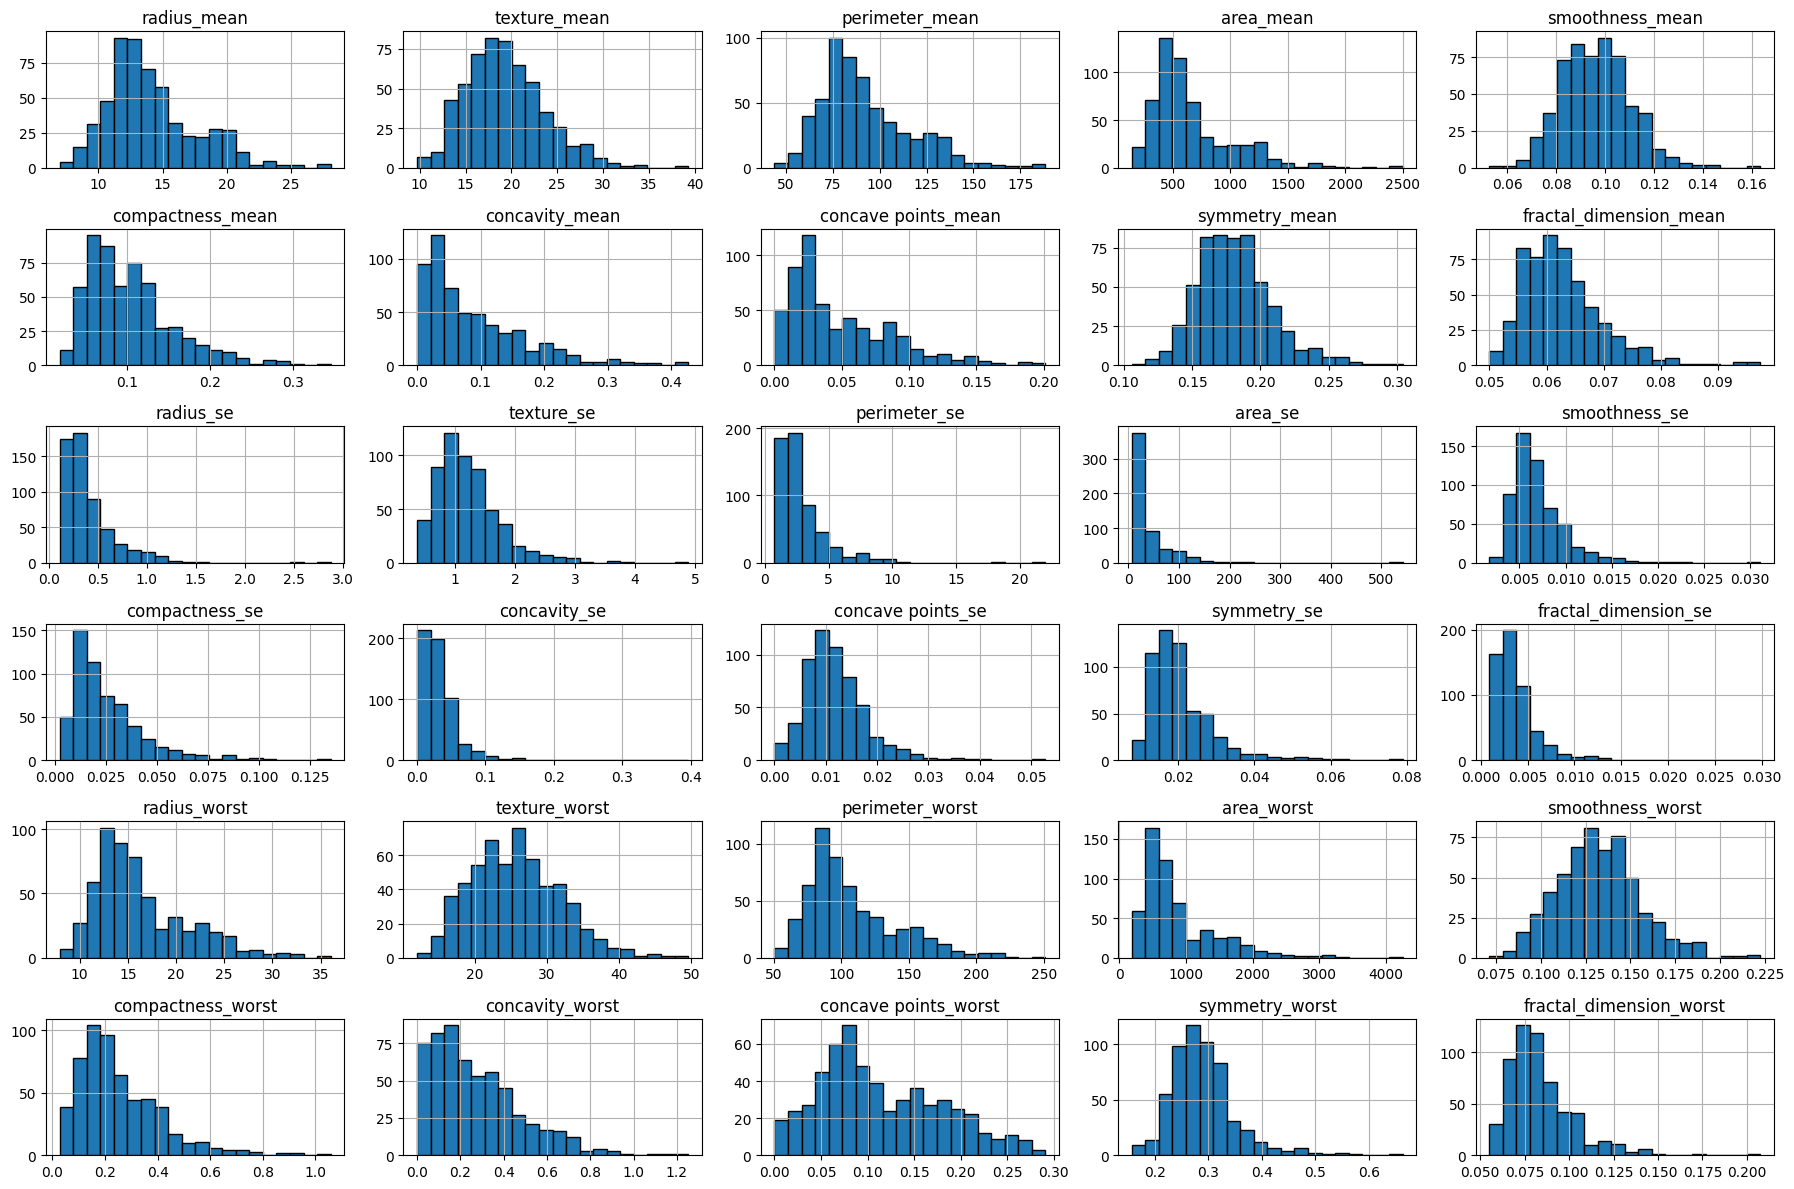

In [6]:
#Realizar histogramas
X_independientes.hist(figsize=(18,12),  bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

In [7]:
#Estandarizar variables independientes

from sklearn.preprocessing import StandardScaler

escalar = StandardScaler()
escalar.fit(X_independientes)

X_independientes_est = escalar.transform(X_independientes)

In [8]:
#Realizar una partición de 

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X_independientes_est, y_dependiente, test_size=0.25, random_state=2026)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN_10 = KNeighborsClassifier(n_neighbors =10)
model_KNN_10.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_10 = model_KNN_10.predict(X_test)
accuracy_10 = accuracy_score(y_test, y_pred_10)
print("El accuracy score que se tiene es %s" %accuracy_10)

El accuracy score que se tiene es 0.972027972027972


Text(50.722222222222214, 0.5, 'Real')

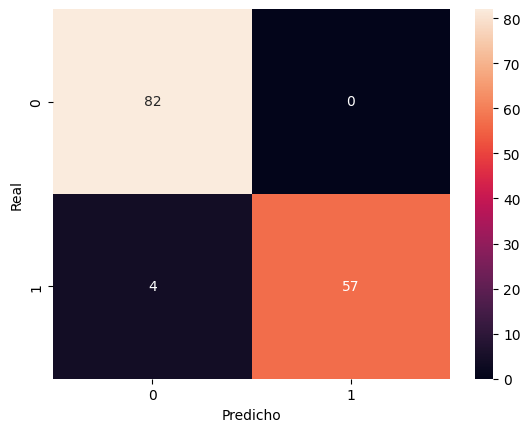

In [11]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_10)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_10 = precision_score(y_test, y_pred_10)
recall_10 = recall_score(y_test, y_pred_10)
f1_10 = f1_score(y_test, y_pred_10)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_10, recall_10,f1_10]})
metricas

,Métricas,Valores
0,Precisión,1.000000
1,Recall,0.934426
2,F1,0.966102


In [13]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN_50 = KNeighborsClassifier(n_neighbors =50)
model_KNN_50.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
#Obtener el accuracy_score
y_pred_50 = model_KNN_50.predict(X_test)
accuracy_50 = accuracy_score(y_test, y_pred_50)
print("El accuracy score que se tiene es %s" %accuracy_50)

El accuracy score que se tiene es 0.9440559440559441


Text(50.722222222222214, 0.5, 'Real')

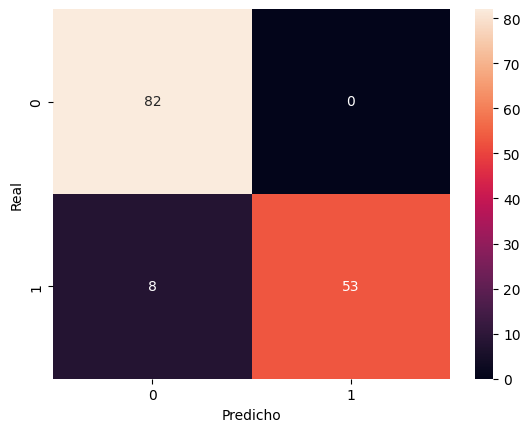

In [15]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_50)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [16]:
#Obtener la presición, recall y f1
precision_50 = precision_score(y_test, y_pred_50)
recall_50 = recall_score(y_test, y_pred_50)
f1_50 = f1_score(y_test, y_pred_50)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_50, recall_50,f1_50]})
metricas

,Métricas,Valores
0,Precisión,1.000000
1,Recall,0.868852
2,F1,0.929825


In [17]:
# Encontrar el valor optimo de K
from sklearn.model_selection import cross_val_score
#Valores de K que vamos a probar

k_range = range(1, 100)
#Inicializar vector de puntuaciones
k_scores = []
# bucle
for k in k_range:
    # ajustar el modelo con k vecinos
    knn = KNeighborsClassifier(n_neighbors=k)
    # obtener puntuaciones de VC
    scores = cross_val_score(knn,X_train,y_train ,cv = 10, scoring = "accuracy")
    # Guardar puntuaciones en el vector
    k_scores.append(scores.mean())

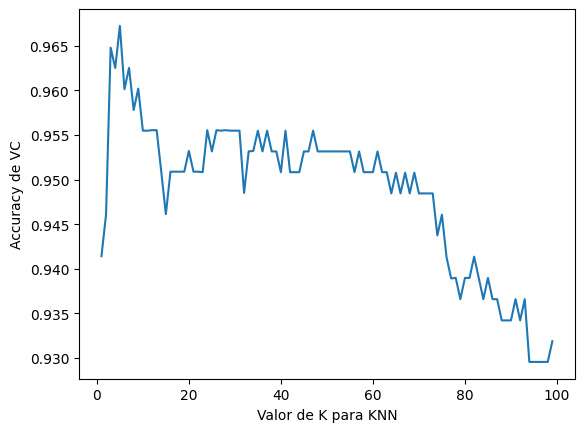

In [18]:
#Representar la validación cruzada
plt.plot(k_range, k_scores)
plt.xlabel('Valor de K para KNN')
plt.ylabel('Accuracy de VC')
plt.show()

In [19]:
print("El valor de K que maximiza la accuracy es", np.argmax(k_scores) + 1)

El valor de K que maximiza la accuracy es 5


In [20]:
#Con el valor de k encontrado se realizará una clasificación para la mediana de todas las variables

model_KNN_5 = KNeighborsClassifier(n_neighbors =5)
model_KNN_5.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
#Obtener la mediana
medianas_x = np.median(X_train, axis=0)
model_KNN_5.predict(medianas_x.reshape(1,-1))

array([0])

Al considerar la mediana de todas las variables se espera que el modelo clasifique a dicha observación en la clase 0.